In [61]:
from __future__ import print_function
#%matplotlib inline
import argparse
import os
import random
import torch
import torch.nn as nn
import csv
import random
import torch.nn.parallel
import torch.backends.cudnn as cudnn
import torch.optim as optim
import torch.utils.data
import torchvision.datasets as dset
import torchvision.transforms as transforms
import torchvision.utils as vutils
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
from IPython.display import HTML
# Set random seed for reproducibility
#manualSeed = 999 #or you can fixe it in a specific value
Seed = random.randint(1, 10000) # use if you want new results
print("Random Seed: ", Seed)
random.seed(Seed)
torch.manual_seed(Seed)

Random Seed:  9484


In [62]:
# Root directory of where you set your dataset
dataroot = "/kaggle/input/celeba-dataset"
# Number of workers for dataloader
workers = 2
# Batch size during training
batch_size = 128
# Spatial size of training images. we will resize All images to this
#   size using a transformer.
image_size = 64
# Number of channels in the training images. For color images this is 3 rbg
nc = 3
# Size of z latent vector (it's the size of the noize vector )
nz = 100
# Size of feature maps in generator
ngf = 64
# Size of feature maps in discriminator
ndf = 64
# Number of training epochs
num_epochs = 10
# Learning rate for optimizers
lr = 0.0002
# Beta1 hyperparam for Adam optimizers
beta1 = 0.5
# Number of GPUs available. Use 0 for CPU mode. & 1 for gpu #mode(like NVIDIA)
ngpu = 1

Generator(
  (main): Sequential(
    (0): ConvTranspose2d(100, 512, kernel_size=(4, 4), stride=(1, 1), bias=False)
    (1): BatchNorm2d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): ConvTranspose2d(512, 256, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (4): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): ReLU(inplace=True)
    (6): ConvTranspose2d(256, 128, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (7): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): ReLU(inplace=True)
    (9): ConvTranspose2d(128, 64, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (10): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): ReLU(inplace=True)
    (12): ConvTranspose2d(64, 3, kernel_size=(4, 4), stride=(2, 2), padding=(1, 1), bias=False)
    (13): Tanh()
  )
)


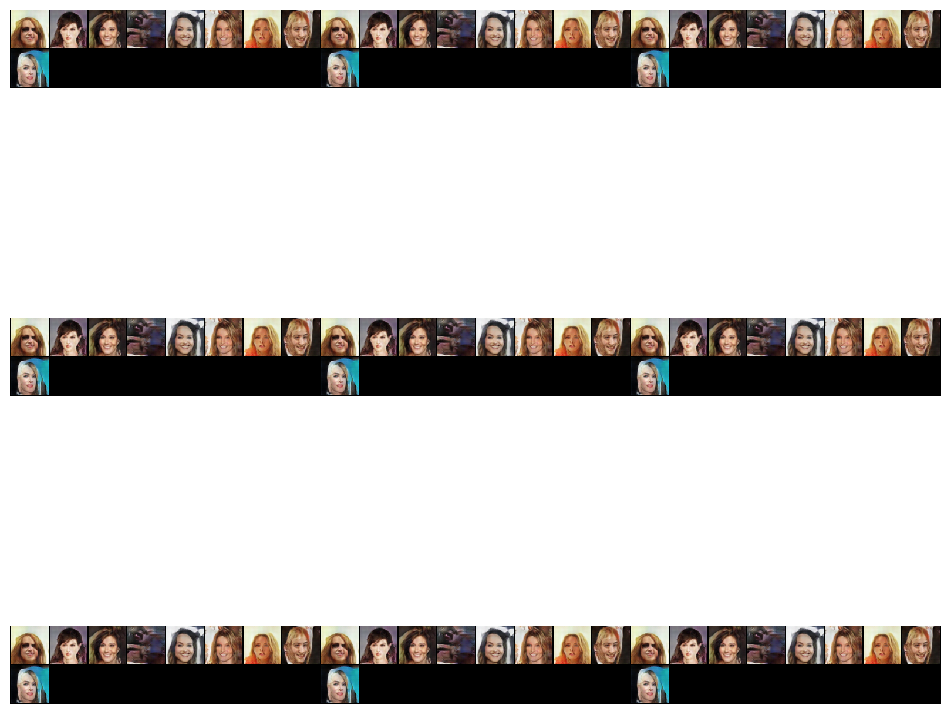

In [63]:
dataset = dset.ImageFolder(root=dataroot,
                               transform=transforms.Compose([
                                   transforms.Resize(image_size),
                                   transforms.CenterCrop(image_size),
                                   transforms.ToTensor(),
                                   transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
                               ]))
    # Create the dataloader
dataloader = torch.utils.data.DataLoader(dataset, batch_size=batch_size,
                                             shuffle=True, num_workers=workers)

class Generator(nn.Module):  # Input is 100x1 and output is 64x64x3
    def __init__(self, ngpu):
        super(Generator, self).__init__()
        self.ngpu = ngpu
        self.main = nn.Sequential(
            # input is Z, going into a convolution
            nn.ConvTranspose2d( nz, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),
            # state size. (ngf*8) x 4 x 4
            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),
            # state size. (ngf*4) x 8 x 8
            nn.ConvTranspose2d( ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),
            # state size. (ngf*2) x 16 x 16
            nn.ConvTranspose2d( ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),
            # state size. (ngf) x 32 x 32
            nn.ConvTranspose2d( ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh()
            # state size. (nc) x 64 x 64
        )
    def forward(self, input):
        return self.main(input)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
def weights_init(m):
    classname = m.__class__.__name__
    if classname.find('Conv') != -1:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif classname.find('BatchNorm') != -1:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

netG = Generator(ngpu).to(device)
# Handle multi-gpu if desired
if (device.type == 'cuda') and (ngpu > 1):
    netG = nn.DataParallel(netG, list(range(ngpu)))
# Apply the weights_init
netG.apply(weights_init)
# Print the model
print(netG)
netG.load_state_dict(torch.load("/kaggle/input/encoder/pytorch/mymodel/1/Generator_epoch_20.pth"))
netG.eval()  # Set the model to evaluation mode if needed

img_list = []
fixed_noise = torch.randn(9, nz, 1, 1, device=device)
for i in range(9):
    with torch.no_grad():
        fake_image = netG(fixed_noise).detach().cpu()
        img_list.append(vutils.make_grid(fake_image, padding=2, normalize=True))
        # Display the 9 generated images
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(12, 12))
for i, ax in enumerate(axes.flat):
    ax.imshow(np.transpose(img_list[i], (1, 2, 0)), interpolation='nearest')
    ax.axis('off')
plt.subplots_adjust(wspace=0, hspace=0)
plt.show()


class Encoder(nn.Module):
    def __init__(self):
        super(Encoder, self).__init__()
        self.main = nn.Sequential(
            nn.Conv2d(3, 64, 3, 1, 1),  # Adjusted kernel size to fit input size
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(64),
            nn.Conv2d(64, 128, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(128),
            nn.Conv2d(128, 256, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(256),
            nn.Conv2d(256, 512, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(512),
            nn.Conv2d(512, 1024, 3, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),
            nn.BatchNorm2d(1024),
            nn.Conv2d(1024, 100, 3, 1, 0),  # Adjusted kernel size to fit input size
            nn.Sigmoid()  # Output in the range [0, 1]
        )

    def forward(self, x):
        return self.main(x)



In [73]:
import pandas as pd
import os
import random

def findimage(csv_path, attributes, values):
    # Load CSV file
    df = pd.read_csv(csv_path)
    
    # Filter DataFrame based on attributes and values
    filtered_df = df.copy()
    for attr, val in zip(attributes, values):
        filtered_df = filtered_df[filtered_df[attr] == val]
    
    # Select a random image from filtered DataFrame
    filename = random.choice(filtered_df['image_id'].tolist())
    
    if filename:
        target_image = dataroot + '/img_align_celeba/img_align_celeba/' + filename
        image = Image.open(target_image)
        transform = transforms.Compose([
            transforms.Resize(image_size),
            transforms.CenterCrop(image_size),
            transforms.ToTensor(),
            transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
        ])
        # Preprocess the image
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        image = transform(image)
        image = image.unsqueeze(0)
        image = image.to(device)
        return image

# Define paths to CSV file
csv_path = '/kaggle/input/celeba-dataset/list_attr_celeba.csv'
# print('ran')

ran


In [74]:
from PIL import Image
import torchvision.transforms as transforms
import torch
from torch.utils.data import DataLoader

encoder = Encoder().to(device)

encoder.load_state_dict(torch.load("/kaggle/input/encoder/pytorch/mymodel/1/Encoder_epoch_18.pth"))
encoder.eval()  # Set the model to evaluation mode if needed

train_loader = DataLoader(dataset, batch_size=512, shuffle=True)

real_batch = next(iter(train_loader))

def showimage(tensor):
    img_list=[]
    with torch.no_grad():
        fake_image = netG(tensor).detach().cpu()
        img_list.append(vutils.make_grid(fake_image,nrow=3, padding=2, normalize=True))


    plt.subplot(1,2,2)
    plt.axis("off")
    plt.imshow(np.transpose(img_list[-1],(1,2,0)))
    plt.show()


from torchvision.utils import make_grid



Men without glasses:


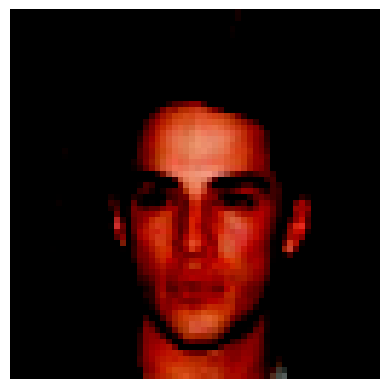

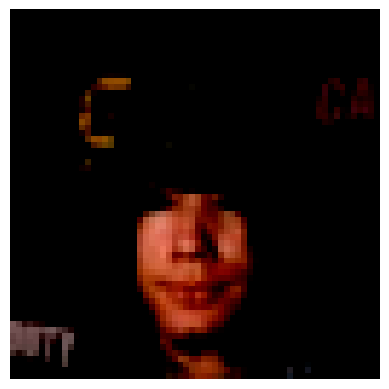

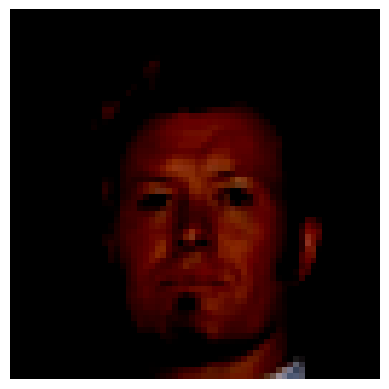

People with glasses:


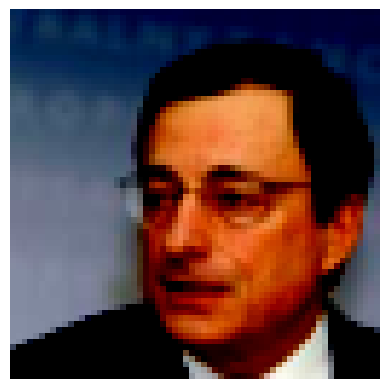

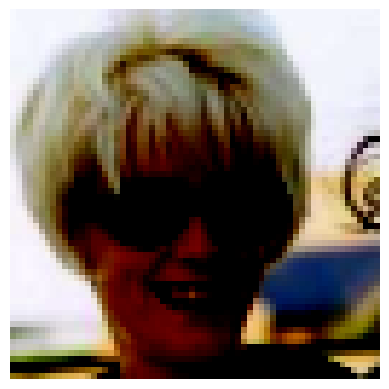

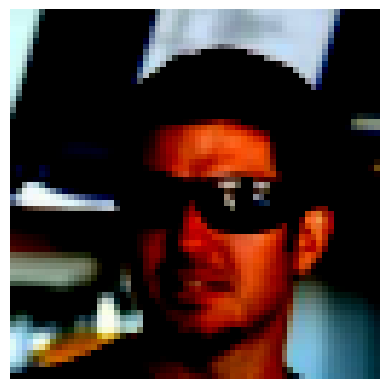

People without glasses:


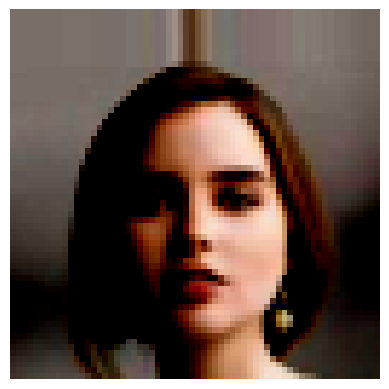

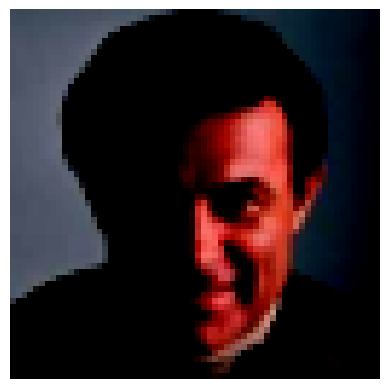

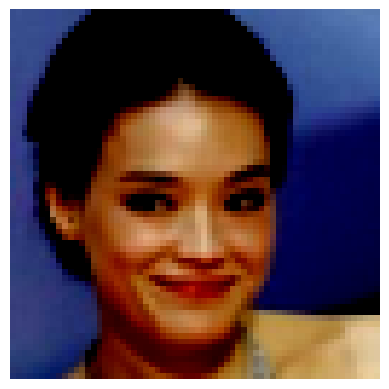

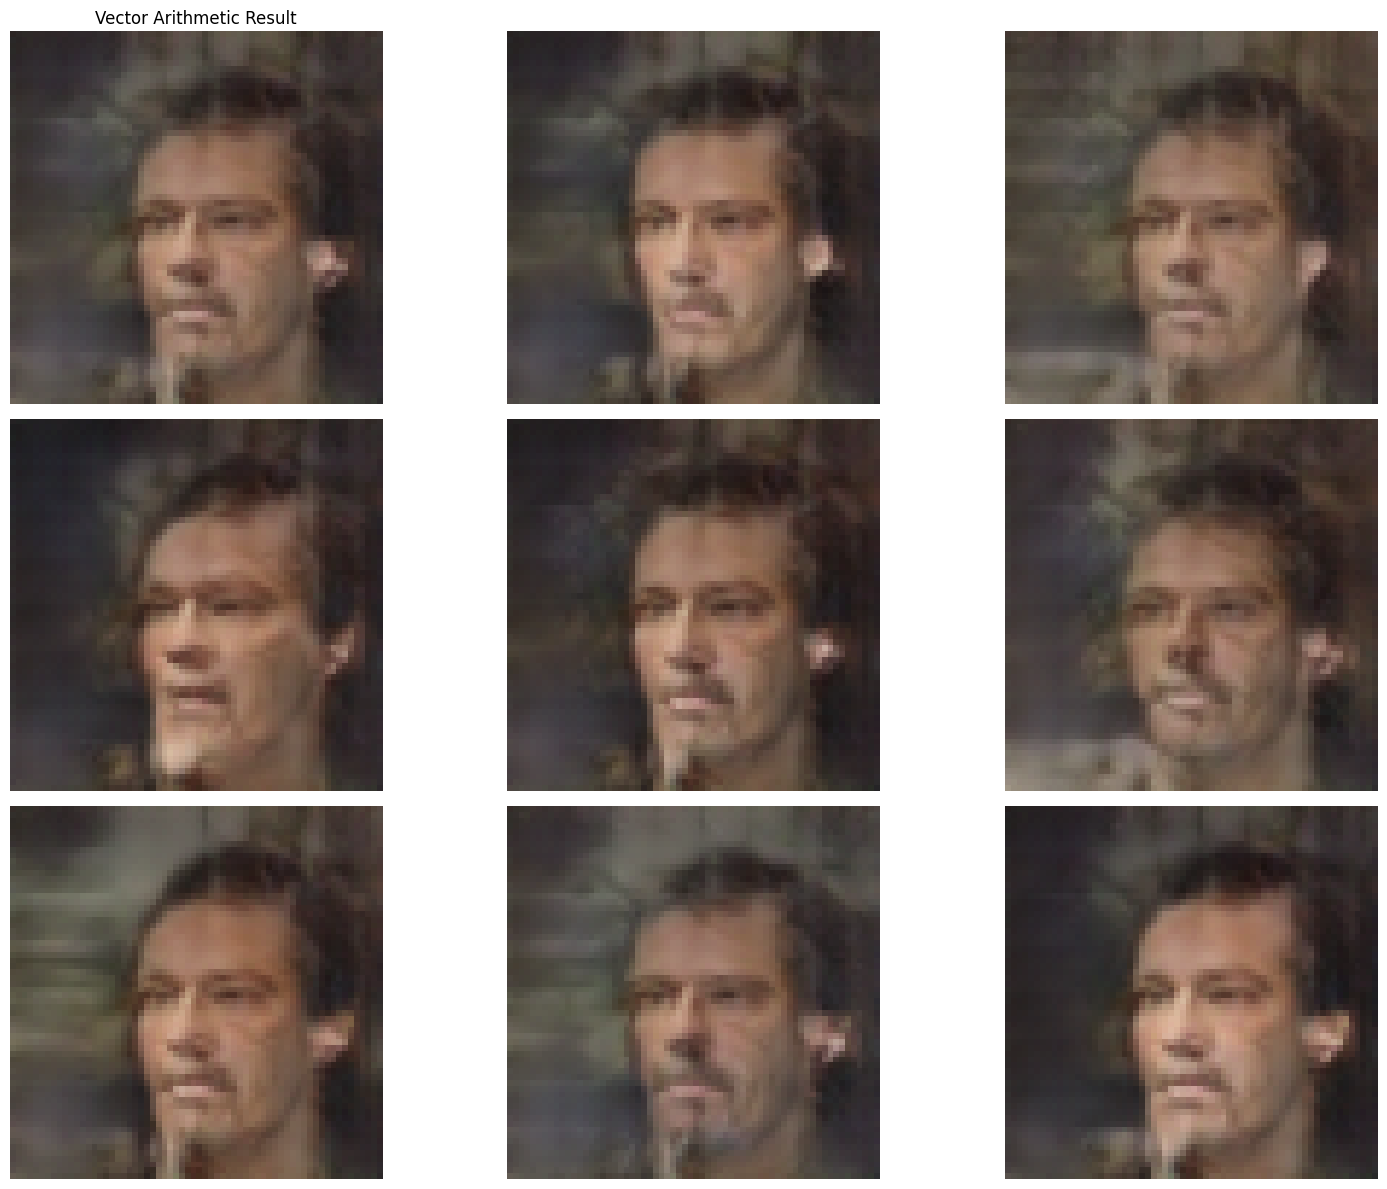

Image for Man without glasses


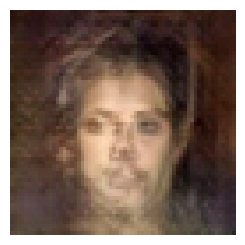

Image for Person with glasses


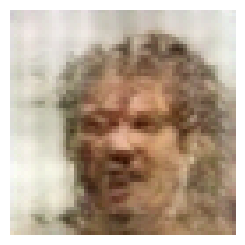

Image for person without glasses


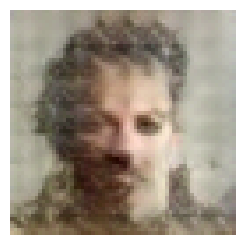

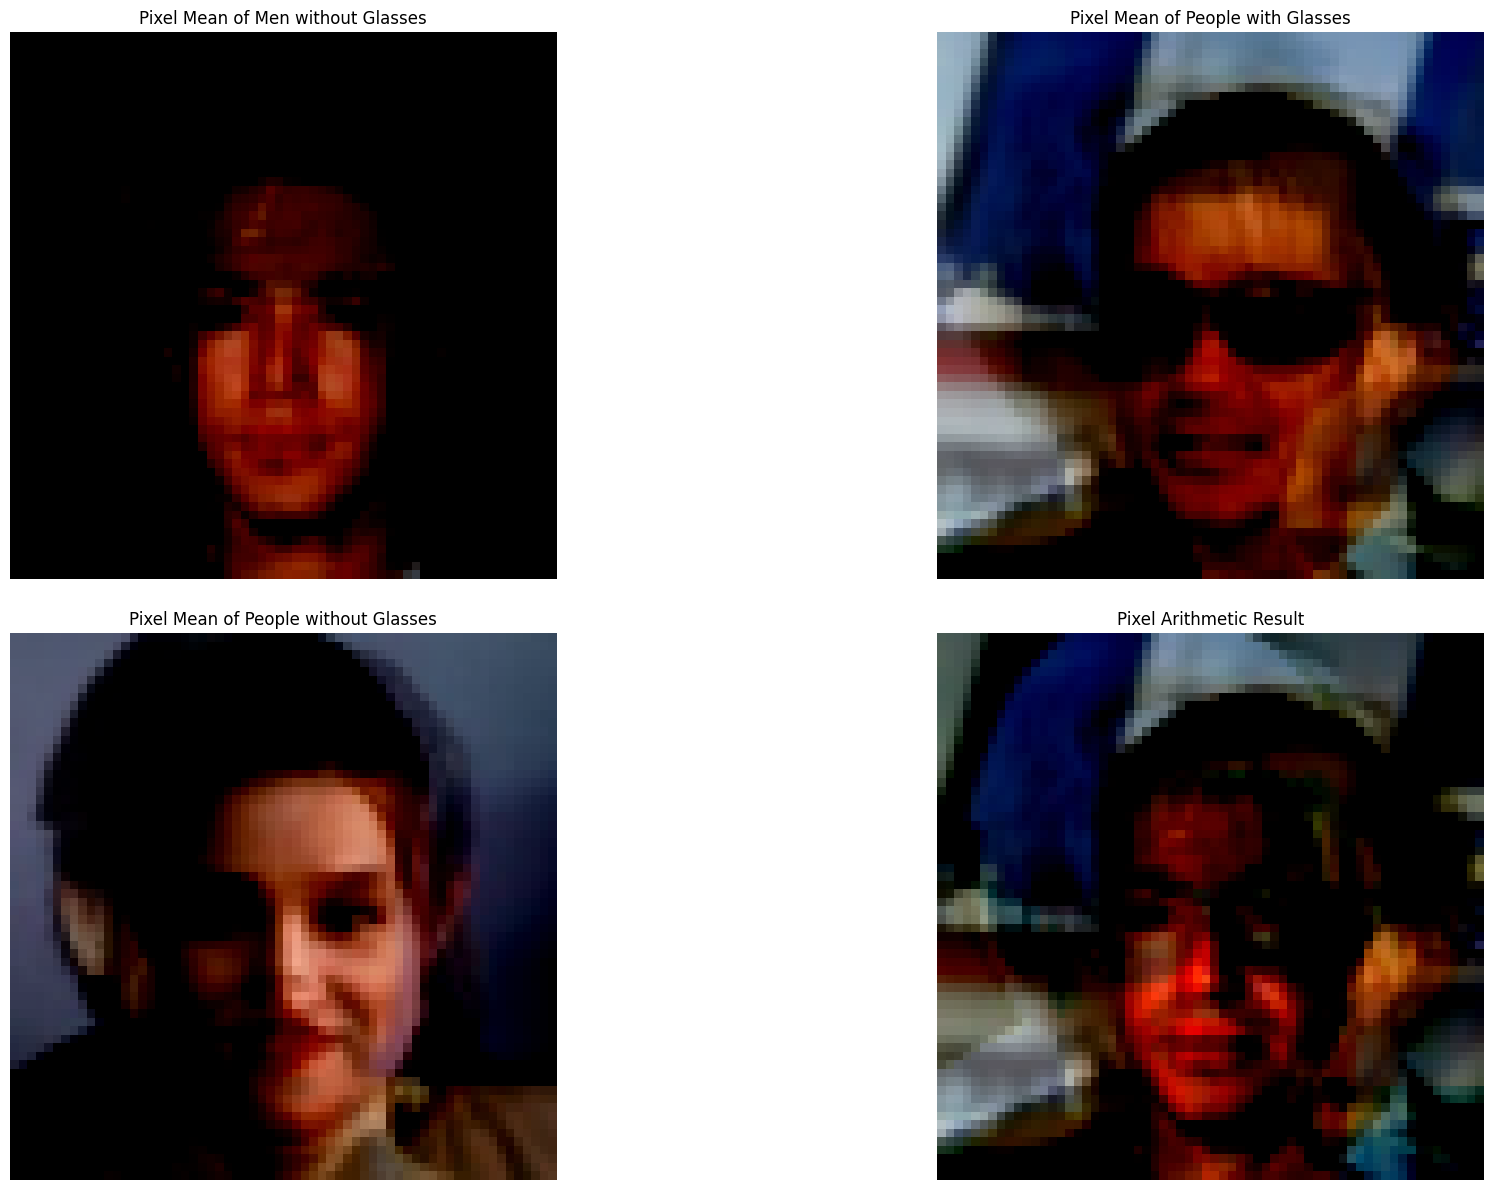

In [89]:
# Men without glasses
mwg1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'],[1, -1])
mwg2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'],[1, -1])
mwg3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'],[1, -1])

# People with glasses
pg1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Eyeglasses'],[1])
pg2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Eyeglasses'],[1])
pg3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Eyeglasses'],[1])

# People without glasses
pwg1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Eyeglasses'],[-1])
pwg2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Eyeglasses'],[-1])
pwg3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Eyeglasses'],[-1])
def show_image(tensor):
    image = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Men without glasses
print("Men without glasses:")
show_image(mwg1)
show_image(mwg2)
show_image(mwg3)

# People with glasses
print("People with glasses:")
show_image(pg1)
show_image(pg2)
show_image(pg3)

# People without glasses
print("People without glasses:")
show_image(pwg1)
show_image(pwg2)
show_image(pwg3)
with torch.no_grad():
    mwg = (encoder(mwg1) + encoder(mwg2) + encoder(mwg3)) / 3
    pg = (encoder(pg1) + encoder(pg2) + encoder(pg3)) / 3
    pwg = (encoder(pwg1) + encoder(pwg2) + encoder(pwg3)) / 3

overall = mwg + pg - pwg
overall = overall[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1)

# Create a figure with 3 rows and 4 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

with torch.no_grad():
    fake_image = netG(overall)

# Denormalize the generated image
fake_image = (fake_image + 1) / 2  # Assuming normalization range is [-1, 1]

# Convert the generated image to a numpy array for plotting
fake_image_numpy = fake_image.detach().cpu().numpy().squeeze()

# Plot the generated image in the first subplot
axes[0, 0].imshow(np.transpose(fake_image_numpy, (1, 2, 0)))
axes[0, 0].set_title("Vector Arithmetic Result")
axes[0, 0].axis('off')


# Replicate the overall vector 8 times
overall_replicated = overall.repeat(8, 1, 1, 1)

# Create a tensor of uniform noise with a scale of ±0.25
noise = torch.rand_like(overall_replicated) * 0.5 - 0.25

# Add the noise to the replicated overall vector
noisy_overall = overall_replicated + noise

# Generate 8 fake images using the noisy overall vector
with torch.no_grad():
    fake_images = netG(noisy_overall)

# Denormalize the generated images
fake_images = (fake_images + 1) / 2  # Assuming normalization range is [-1, 1]

# Convert the generated images to numpy arrays for plotting
fake_images_numpy = fake_images.detach().cpu().numpy()

# Plot the generated images in the remaining columns
for i, ax in enumerate(axes.flat[1:]):
    ax.imshow(np.transpose(fake_images_numpy[i-3], (1, 2, 0)))
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Image for Man without glasses")
showimage(mwg[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

print("Image for Person with glasses")
showimage(pg[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

print("Image for person without glasses")
showimage(pwg[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

# Calculate pixel mean for each condition
mwg_pixel_mean = np.clip((mwg1.cpu().numpy() + mwg2.cpu().numpy() + mwg3.cpu().numpy()) / 3, 0, 1)
pg_pixel_mean = np.clip((pg1.cpu().numpy() + pg2.cpu().numpy() + pg3.cpu().numpy()) / 3, 0, 1)
pwg_pixel_mean = np.clip((pwg1.cpu().numpy() + pwg2.cpu().numpy() + pwg3.cpu().numpy()) / 3, 0, 1)

# Calculate average value of all mean images
average_value = (mwg_pixel_mean.mean() + pg_pixel_mean.mean() + pwg_pixel_mean.mean()) / 3

# Perform vector arithmetic in pixel space
pixel_result = mwg_pixel_mean + pg_pixel_mean - pwg_pixel_mean

# Normalize the pixel result
pixel_result = np.clip(pixel_result, 0, 1)

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# Plot the pixel mean images
axes[0, 0].imshow(np.transpose(mwg_pixel_mean.squeeze(), (1, 2, 0)))
axes[0, 0].set_title("Pixel Mean of Men without Glasses")
axes[0, 0].axis('off')

axes[0, 1].imshow(np.transpose(pg_pixel_mean.squeeze(), (1, 2, 0)))
axes[0, 1].set_title("Pixel Mean of People with Glasses")
axes[0, 1].axis('off')

axes[1, 0].imshow(np.transpose(pwg_pixel_mean.squeeze(), (1, 2, 0)))
axes[1, 0].set_title("Pixel Mean of People without Glasses")
axes[1, 0].axis('off')

# Plot the pixel arithmetic result
axes[1, 1].imshow(np.transpose(pixel_result.squeeze(), (1, 2, 0)))
axes[1, 1].set_title("Pixel Arithmetic Result")
axes[1, 1].axis('off')

plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


Men with glasses:


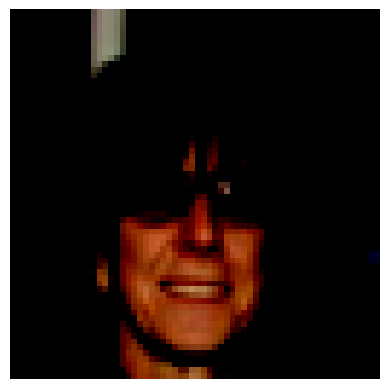

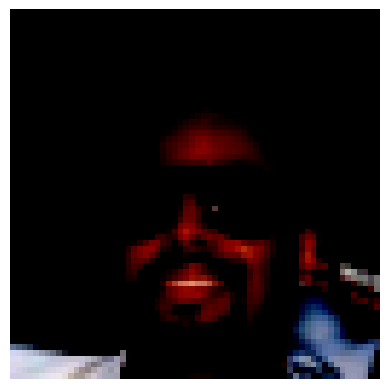

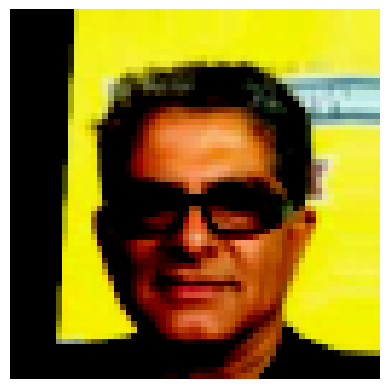

Men without glasses:


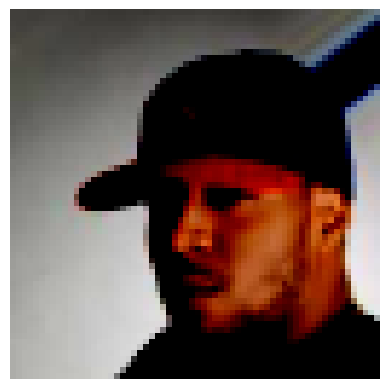

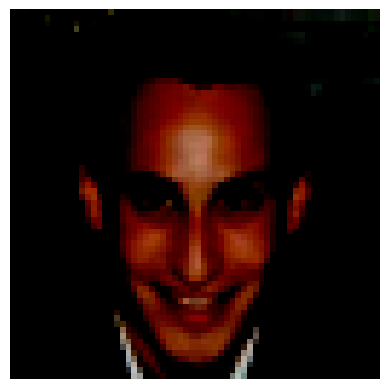

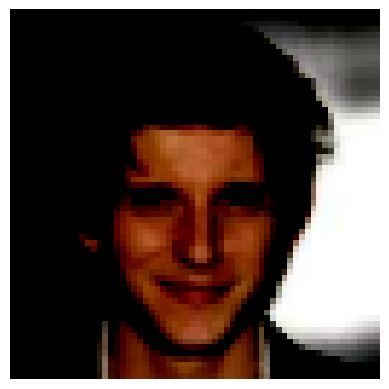

Women without glasses:


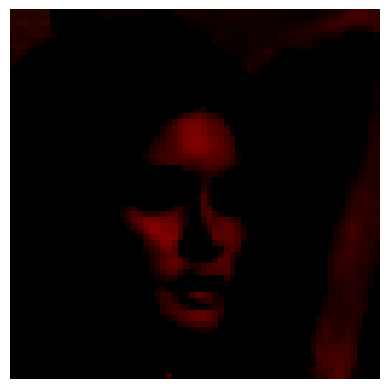

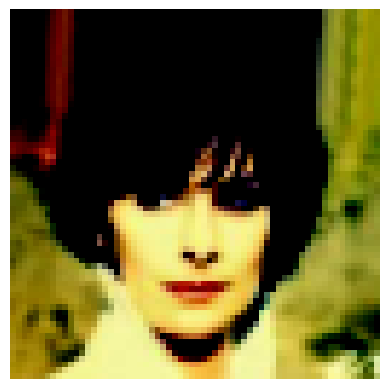

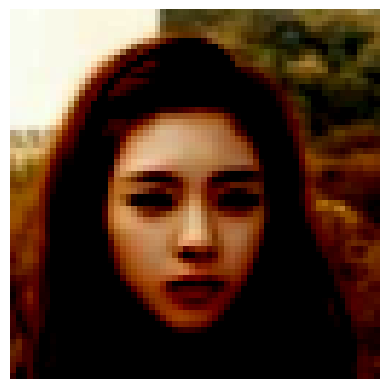

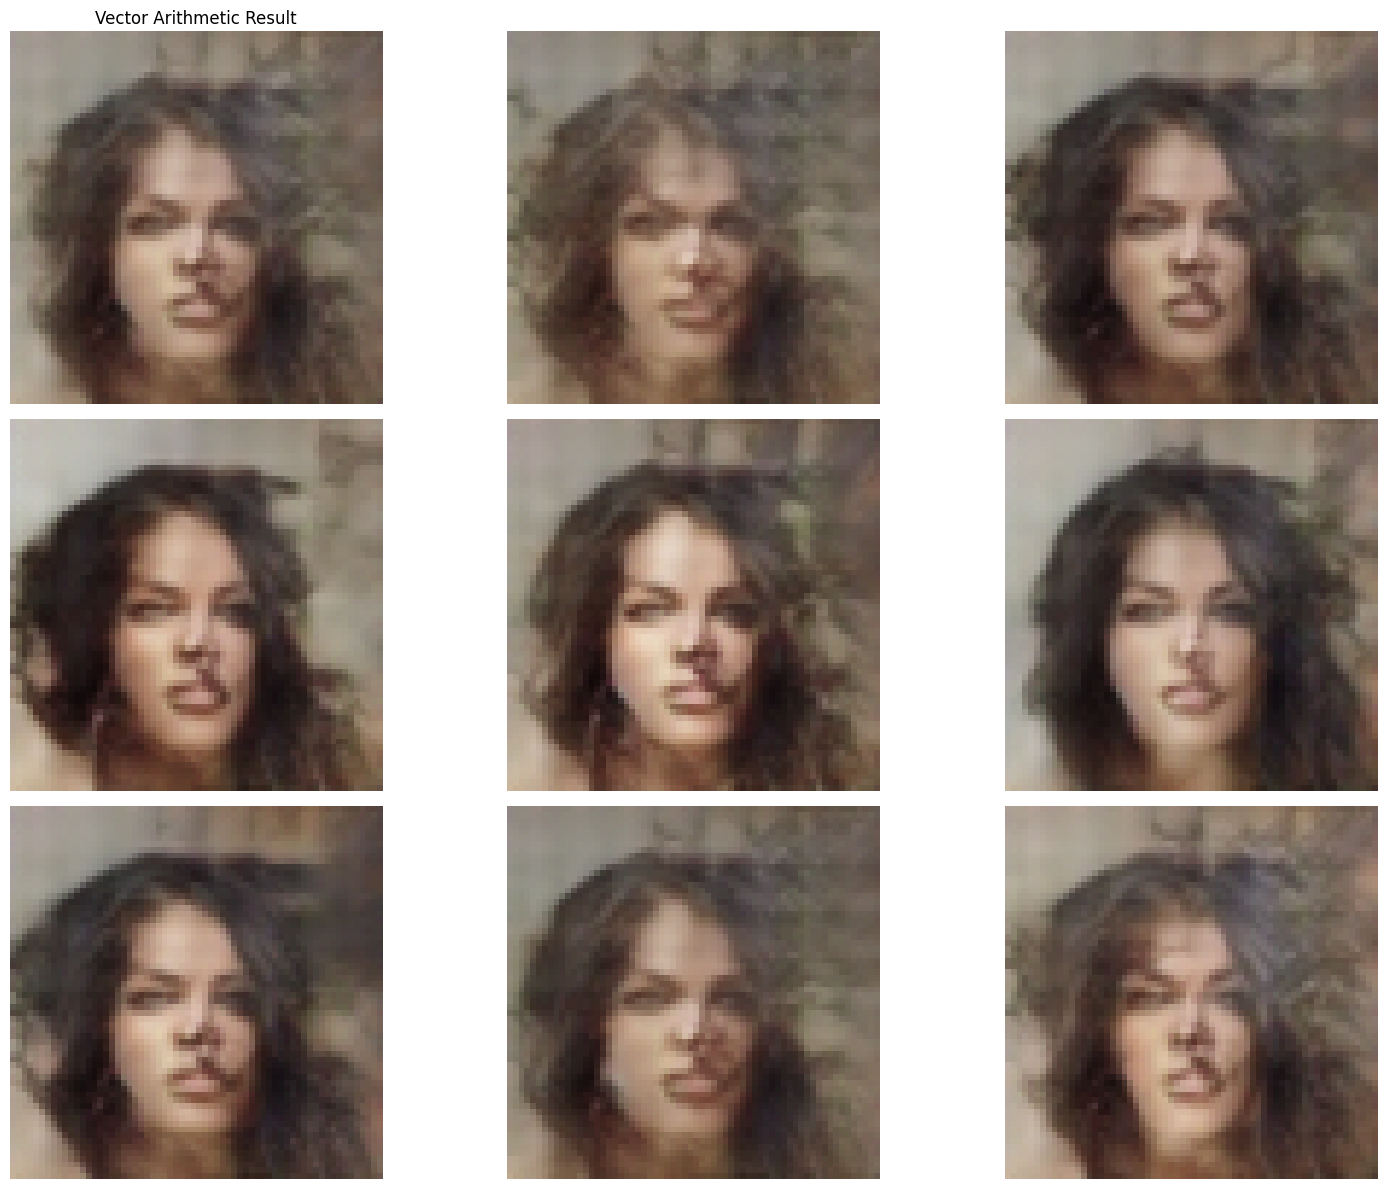

Image for Man with glasses


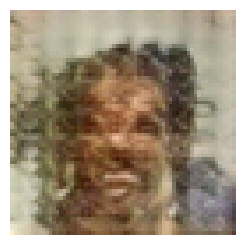

Image for Men without glasses


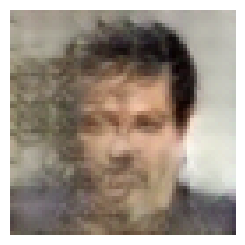

Image for Woman without glasses


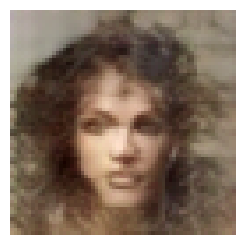

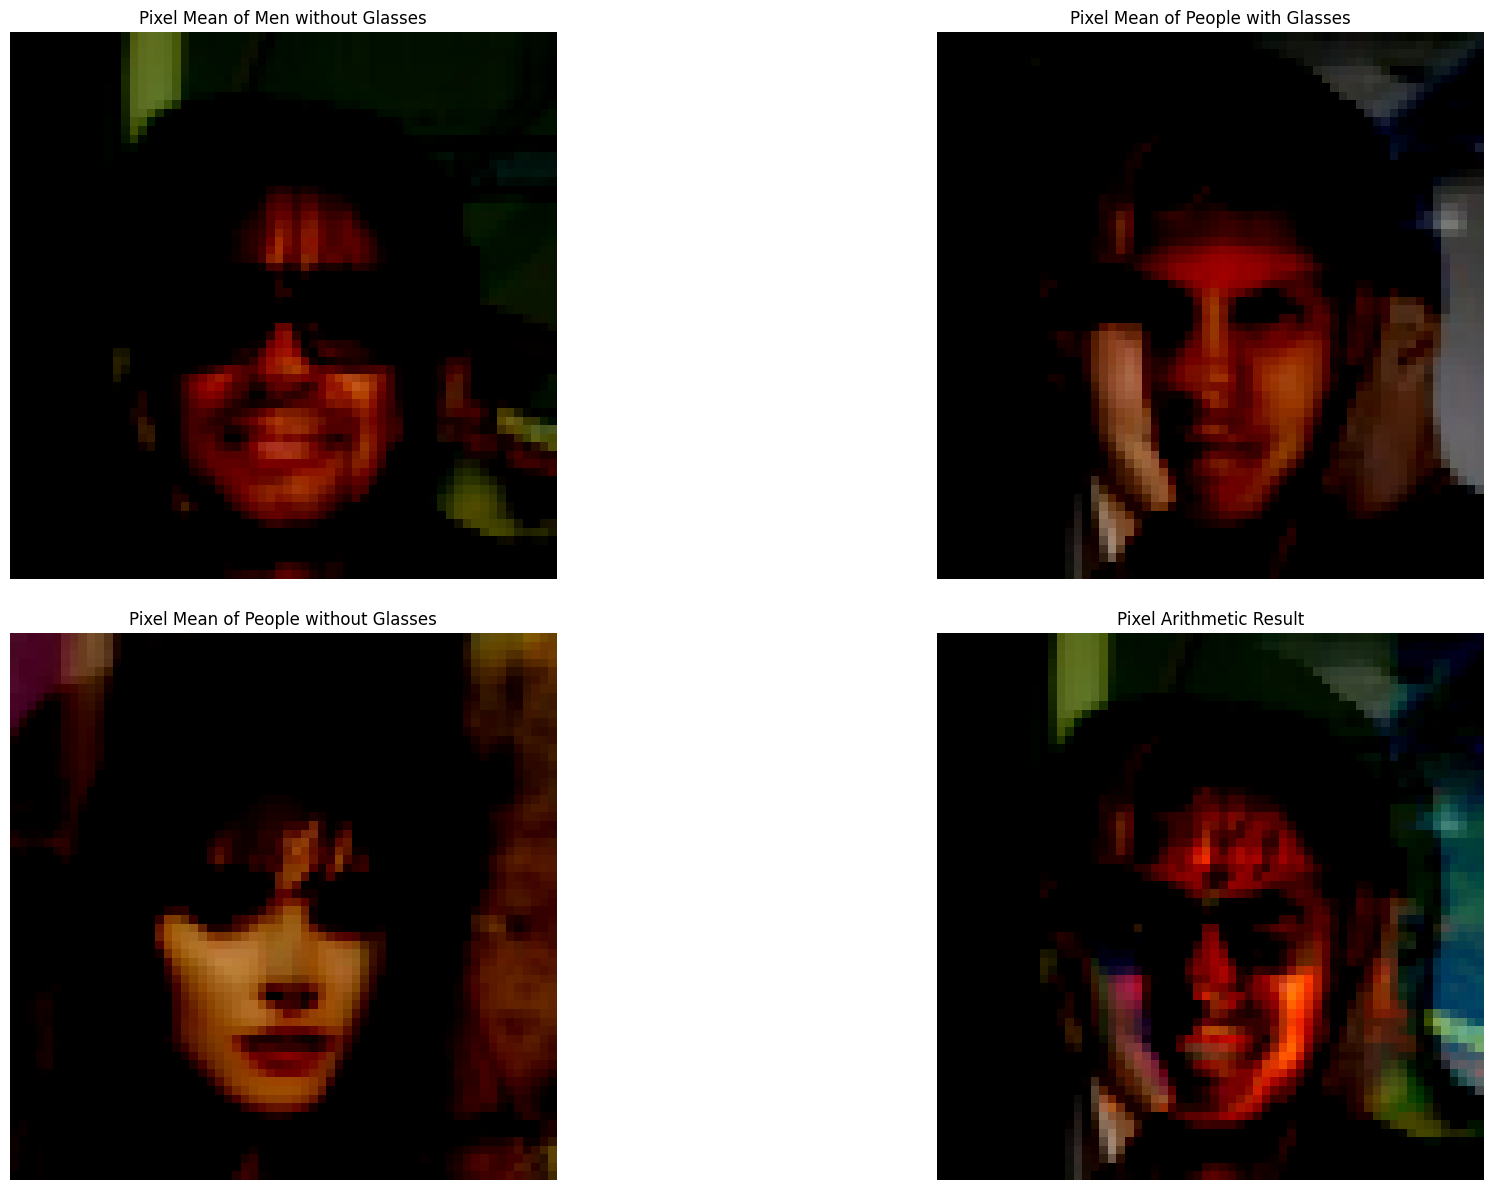

In [90]:
mwg1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [1, 1])
mwg2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [1, 1])
mwg3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [1, 1])

pg1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [1, -1])
pg2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [1, -1])
pg3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [1, -1])

pwg1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [-1, -1])
pwg2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [-1, -1])
pwg3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Eyeglasses'], [-1, -1])

def show_image(tensor):
    image = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Men without glasses
print("Men with glasses:")
show_image(mwg1)
show_image(mwg2)
show_image(mwg3)

# People with glasses
print("Men without glasses:")
show_image(pg1)
show_image(pg2)
show_image(pg3)

# People without glasses
print("Women without glasses:")
show_image(pwg1)
show_image(pwg2)
show_image(pwg3)
with torch.no_grad():
    mwg = (encoder(mwg1) + encoder(mwg2) + encoder(mwg3)) / 3
    pg = (encoder(pg1) + encoder(pg2) + encoder(pg3)) / 3
    pwg = (encoder(pwg1) + encoder(pwg2) + encoder(pwg3)) / 3

overall = mwg - pg + pwg
overall = overall[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1)

# Create a figure with 3 rows and 4 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

with torch.no_grad():
    fake_image = netG(overall)

# Denormalize the generated image
fake_image = (fake_image + 1) / 2  # Assuming normalization range is [-1, 1]

# Convert the generated image to a numpy array for plotting
fake_image_numpy = fake_image.detach().cpu().numpy().squeeze()

# Plot the generated image in the first subplot
axes[0, 0].imshow(np.transpose(fake_image_numpy, (1, 2, 0)))
axes[0, 0].set_title("Vector Arithmetic Result")
axes[0, 0].axis('off')


# Replicate the overall vector 8 times
overall_replicated = overall.repeat(8, 1, 1, 1)

# Create a tensor of uniform noise with a scale of ±0.25
noise = torch.rand_like(overall_replicated) * 0.5 - 0.25

# Add the noise to the replicated overall vector
noisy_overall = overall_replicated + noise

# Generate 8 fake images using the noisy overall vector
with torch.no_grad():
    fake_images = netG(noisy_overall)

# Denormalize the generated images
fake_images = (fake_images + 1) / 2  # Assuming normalization range is [-1, 1]

# Convert the generated images to numpy arrays for plotting
fake_images_numpy = fake_images.detach().cpu().numpy()

# Plot the generated images in the remaining columns
for i, ax in enumerate(axes.flat[1:]):
    ax.imshow(np.transpose(fake_images_numpy[i-3], (1, 2, 0)))
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Image for Man with glasses")
showimage(mwg[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

print("Image for Men without glasses")
showimage(pg[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

print("Image for Woman without glasses")
showimage(pwg[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

# Calculate pixel mean for each condition
mwg_pixel_mean = np.clip((mwg1.cpu().numpy() + mwg2.cpu().numpy() + mwg3.cpu().numpy()) / 3, 0, 1)
pg_pixel_mean = np.clip((pg1.cpu().numpy() + pg2.cpu().numpy() + pg3.cpu().numpy()) / 3, 0, 1)
pwg_pixel_mean = np.clip((pwg1.cpu().numpy() + pwg2.cpu().numpy() + pwg3.cpu().numpy()) / 3, 0, 1)

# Calculate average value of all mean images
average_value = (mwg_pixel_mean.mean() + pg_pixel_mean.mean() + pwg_pixel_mean.mean()) / 3

# Perform vector arithmetic in pixel space
pixel_result = mwg_pixel_mean + pg_pixel_mean - pwg_pixel_mean

# Normalize the pixel result
pixel_result = np.clip(pixel_result, 0, 1)

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(18, 12))

# Plot the pixel mean images
axes[0, 0].imshow(np.transpose(mwg_pixel_mean.squeeze(), (1, 2, 0)))
axes[0, 0].set_title("Pixel Mean of Men without Glasses")
axes[0, 0].axis('off')

axes[0, 1].imshow(np.transpose(pg_pixel_mean.squeeze(), (1, 2, 0)))
axes[0, 1].set_title("Pixel Mean of People with Glasses")
axes[0, 1].axis('off')

axes[1, 0].imshow(np.transpose(pwg_pixel_mean.squeeze(), (1, 2, 0)))
axes[1, 0].set_title("Pixel Mean of People without Glasses")
axes[1, 0].axis('off')

# Plot the pixel arithmetic result
axes[1, 1].imshow(np.transpose(pixel_result.squeeze(), (1, 2, 0)))
axes[1, 1].set_title("Pixel Arithmetic Result")
axes[1, 1].axis('off')


plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()


Smiling Men:


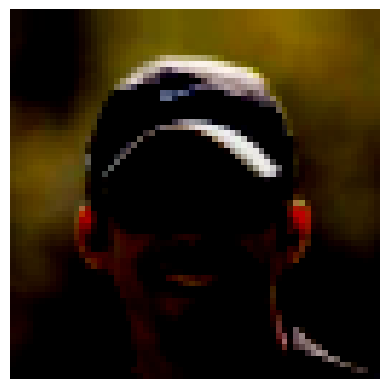

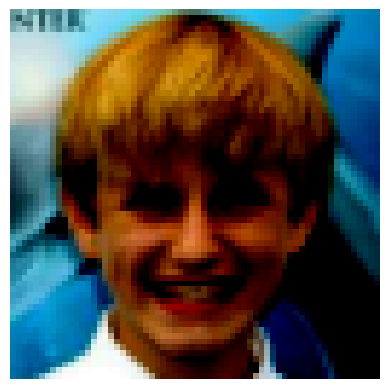

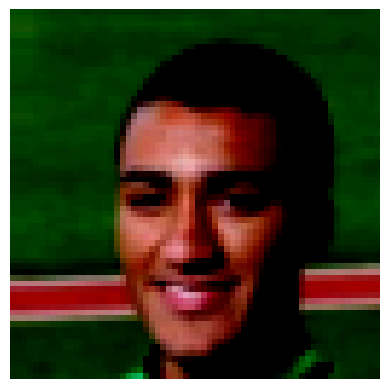

People with Hat:


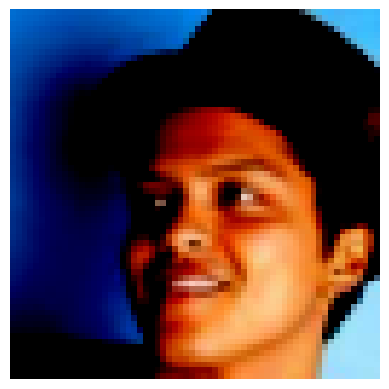

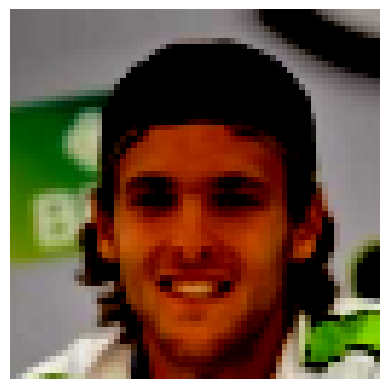

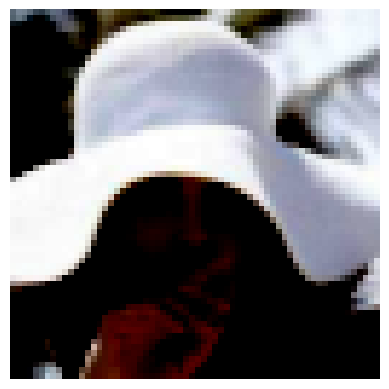

People with Mustache:


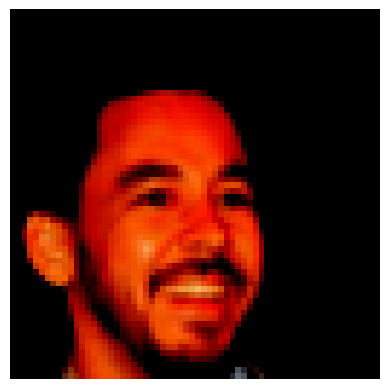

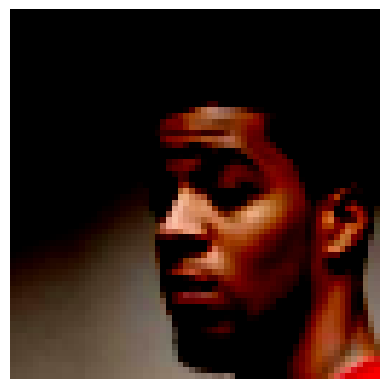

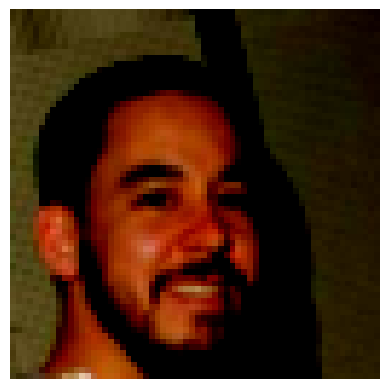

People without Mustache:


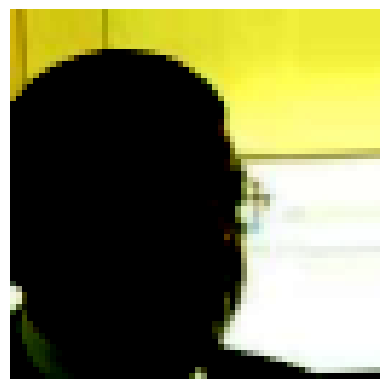

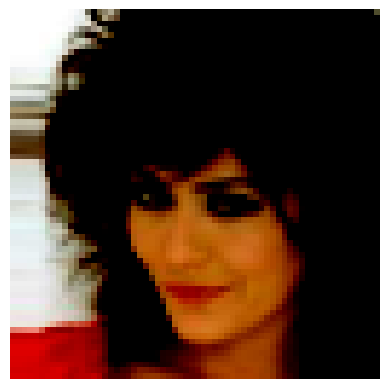

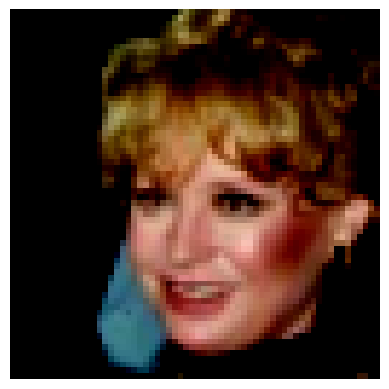

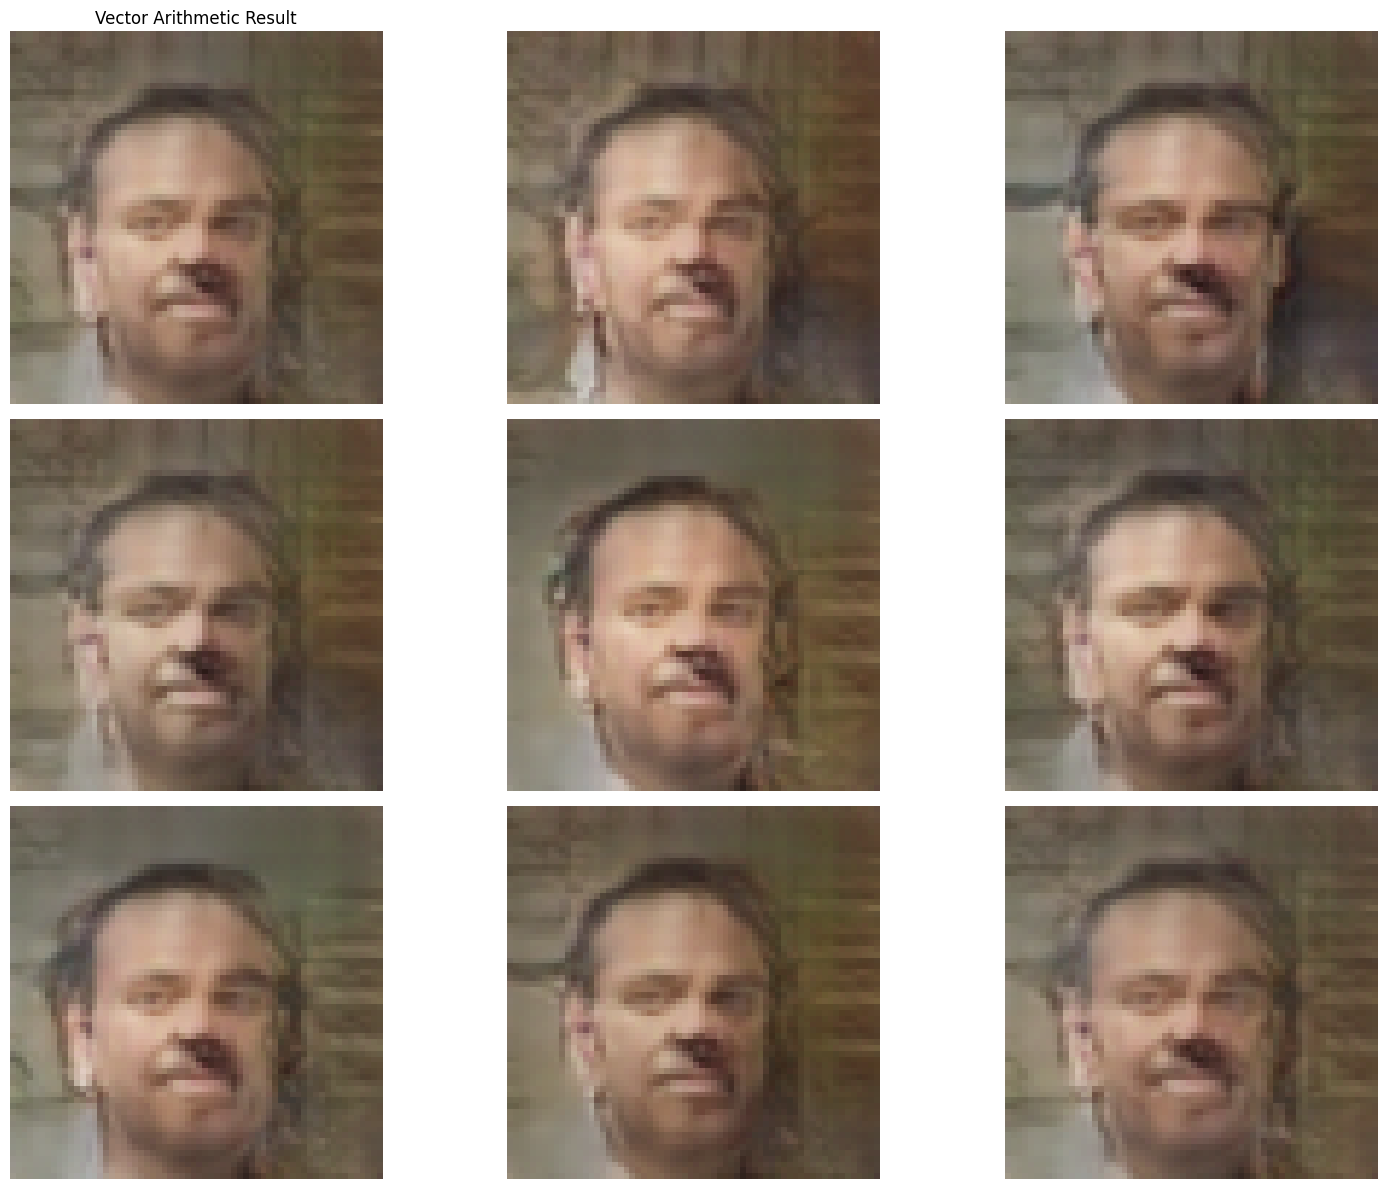

Image for Smiling Men


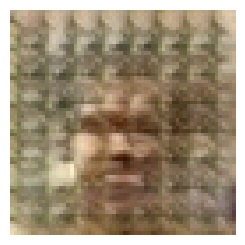

Image for People with Hat


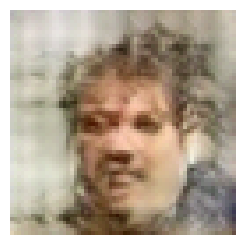

Image for People with Mustache


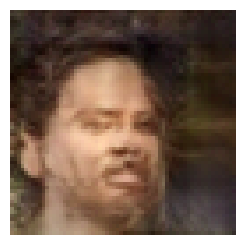

Image for People without Mustache


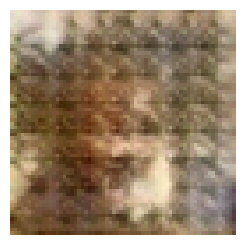

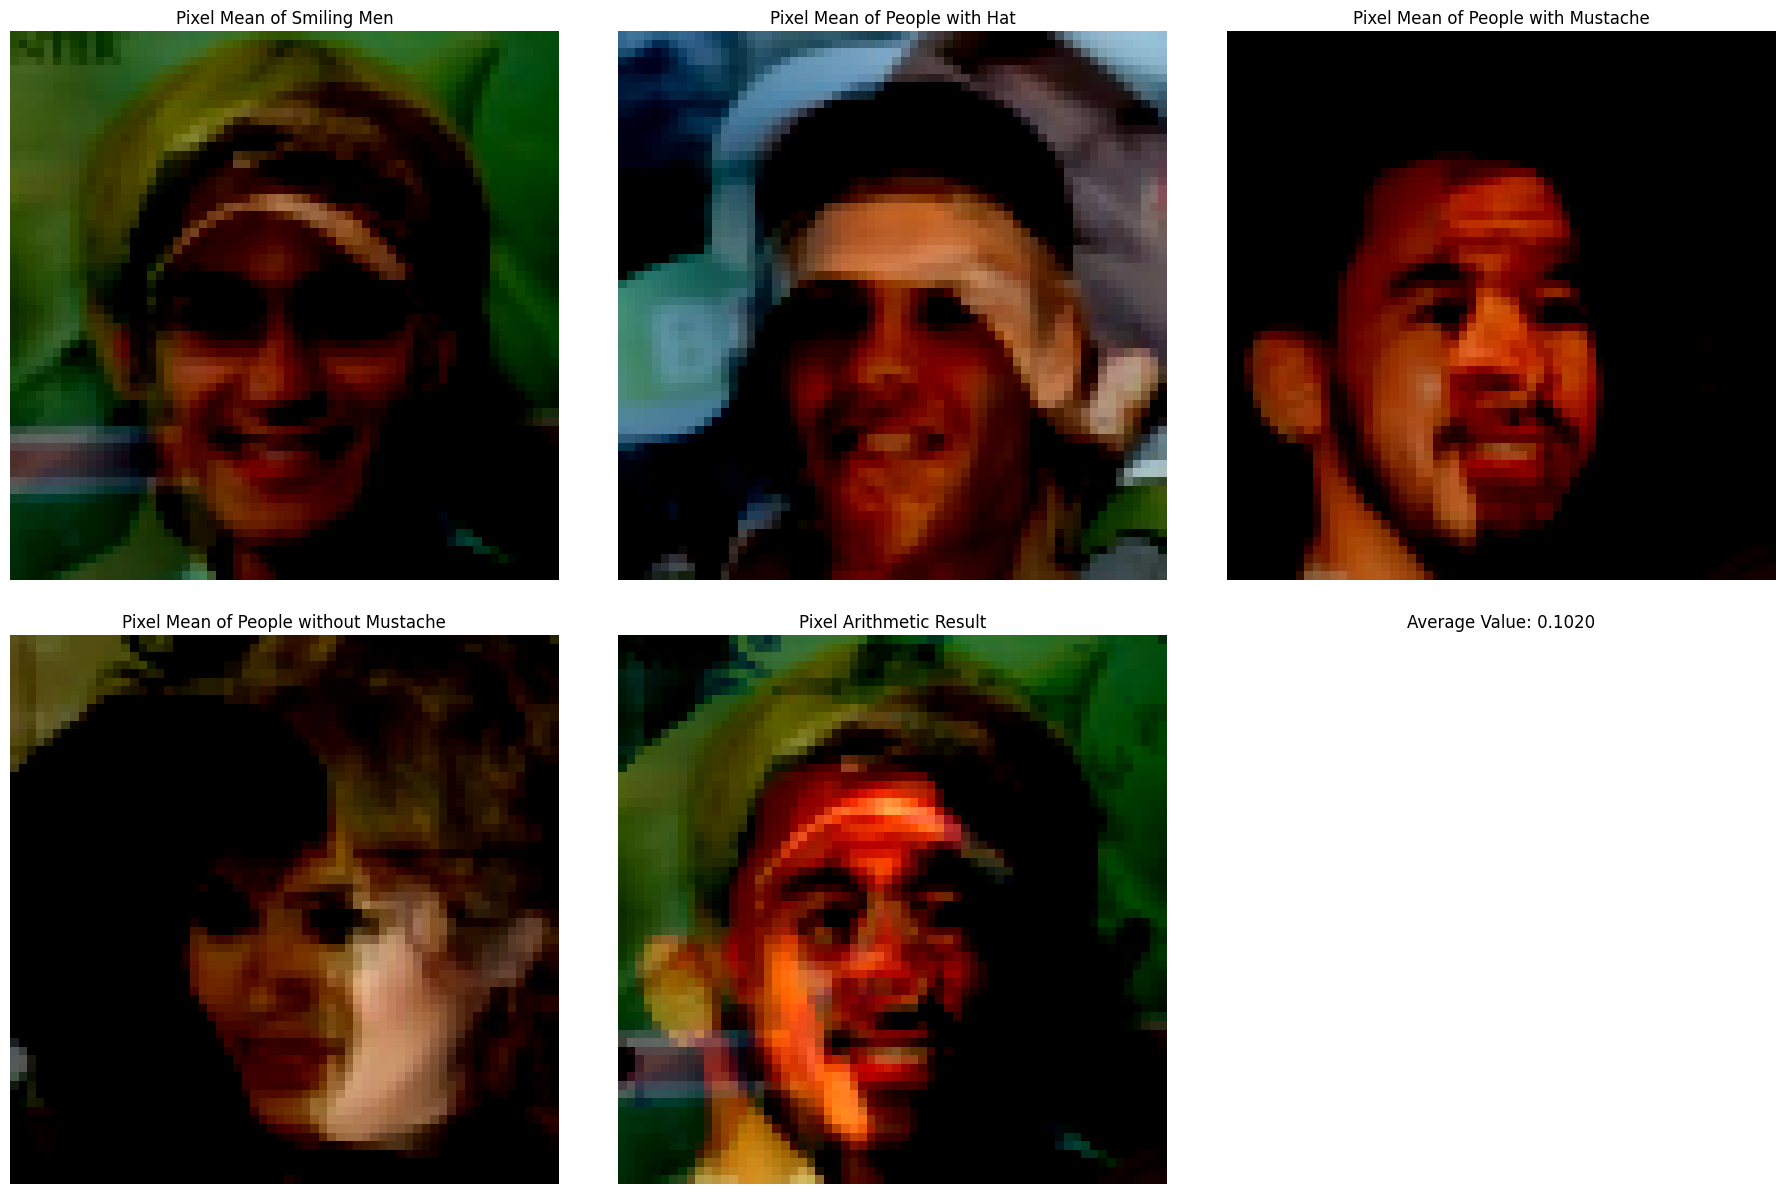

In [92]:
sm1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Smiling'], [1, 1])
sm2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Smiling'], [1, 1])
sm3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Male', 'Smiling'], [1, 1])

pwh1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Wearing_Hat'], [1])
pwh2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Wearing_Hat'], [1])
pwh3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Wearing_Hat'], [1])

pwm1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Mustache'], [1])
pwm2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Mustache'], [1])
pwm3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Mustache'], [1])

pwom1 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Mustache'], [-1])
pwom2 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Mustache'], [-1])
pwom3 = findimage('/kaggle/input/celeba-dataset/list_attr_celeba.csv', ['Mustache'], [-1])

def show_image(tensor):
    image = tensor.squeeze(0).permute(1, 2, 0).cpu().numpy()
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# Smiling Men
print("Smiling Men:")
show_image(sm1)
show_image(sm2)
show_image(sm3)

# People with Hat
print("People with Hat:")
show_image(pwh1)
show_image(pwh2)
show_image(pwh3)

# People with Mustache
print("People with Mustache:")
show_image(pwm1)
show_image(pwm2)
show_image(pwm3)

# People without Mustache
print("People without Mustache:")
show_image(pwom1)
show_image(pwom2)
show_image(pwom3)

with torch.no_grad():
    sm = (encoder(sm1) + encoder(sm2) + encoder(sm3)) / 3
    pwh = (encoder(pwh1) + encoder(pwh2) + encoder(pwh3)) / 3
    pwm = (encoder(pwm1) + encoder(pwm2) + encoder(pwm3)) / 3
    pwom = (encoder(pwom1) + encoder(pwom2) + encoder(pwom3)) / 3

overall = sm + pwh - pwh + pwm - pwom
overall = overall[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1)

# Create a figure with 3 rows and 4 columns
fig, axes = plt.subplots(nrows=3, ncols=3, figsize=(16, 12))

with torch.no_grad():
    fake_image = netG(overall)

# Denormalize the generated image
fake_image = (fake_image + 1) / 2  # Assuming normalization range is [-1, 1]

# Convert the generated image to a numpy array for plotting
fake_image_numpy = fake_image.detach().cpu().numpy().squeeze()

# Plot the generated image in the first subplot
axes[0, 0].imshow(np.transpose(fake_image_numpy, (1, 2, 0)))
axes[0, 0].set_title("Vector Arithmetic Result")
axes[0, 0].axis('off')

# Replicate the overall vector 8 times
overall_replicated = overall.repeat(8, 1, 1, 1)

# Create a tensor of uniform noise with a scale of ±0.25
noise = torch.rand_like(overall_replicated) * 0.5 - 0.25

# Add the noise to the replicated overall vector
noisy_overall = overall_replicated + noise

# Generate 8 fake images using the noisy overall vector
with torch.no_grad():
    fake_images = netG(noisy_overall)

# Denormalize the generated images
fake_images = (fake_images + 1) / 2  # Assuming normalization range is [-1, 1]

# Convert the generated images to numpy arrays for plotting
fake_images_numpy = fake_images.detach().cpu().numpy()

# Plot the generated images in the remaining columns
for i, ax in enumerate(axes.flat[1:]):
    ax.imshow(np.transpose(fake_images_numpy[i-3], (1, 2, 0)))
    ax.axis('off')

plt.tight_layout()
plt.show()

print("Image for Smiling Men")
showimage(sm[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

print("Image for People with Hat")
showimage(pwh[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

print("Image for People with Mustache")
showimage(pwm[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

print("Image for People without Mustache")
showimage(pwom[:, :, 0, 0].unsqueeze(-1).unsqueeze(-1))

# Calculate pixel mean for each condition
sm_pixel_mean = np.clip((sm1.cpu().numpy() + sm2.cpu().numpy() + sm3.cpu().numpy()) / 3, 0, 1)
pwh_pixel_mean = np.clip((pwh1.cpu().numpy() + pwh2.cpu().numpy() + pwh3.cpu().numpy()) / 3, 0, 1)
pwm_pixel_mean = np.clip((pwm1.cpu().numpy() + pwm2.cpu().numpy() + pwm3.cpu().numpy()) / 3, 0, 1)
pwom_pixel_mean = np.clip((pwom1.cpu().numpy() + pwom2.cpu().numpy() + pwom3.cpu().numpy()) / 3, 0, 1)

# Calculate average value of all mean images
average_value = (sm_pixel_mean.mean() + pwh_pixel_mean.mean() + pwm_pixel_mean.mean() + pwom_pixel_mean.mean()) / 4

# Perform vector arithmetic in pixel space
pixel_result = sm_pixel_mean + pwh_pixel_mean - pwh_pixel_mean + pwm_pixel_mean - pwom_pixel_mean

# Normalize the pixel result
pixel_result = np.clip(pixel_result, 0, 1)

# Create a figure with 2 rows and 3 columns
fig, axes = plt.subplots(nrows=2, ncols=3, figsize=(18, 12))

# Plot the pixel mean images
axes[0, 0].imshow(np.transpose(sm_pixel_mean.squeeze(), (1, 2, 0)))
axes[0, 0].set_title("Pixel Mean of Smiling Men")
axes[0, 0].axis('off')

axes[0, 1].imshow(np.transpose(pwh_pixel_mean.squeeze(), (1, 2, 0)))
axes[0, 1].set_title("Pixel Mean of People with Hat")
axes[0, 1].axis('off')

axes[0, 2].imshow(np.transpose(pwm_pixel_mean.squeeze(), (1, 2, 0)))
axes[0, 2].set_title("Pixel Mean of People with Mustache")
axes[0, 2].axis('off')
axes[1, 0].imshow(np.transpose(pwom_pixel_mean.squeeze(), (1, 2, 0)))
axes[1, 0].set_title("Pixel Mean of People without Mustache")
axes[1, 0].axis('off')
# Plot the pixel arithmetic result
axes[1, 1].imshow(np.transpose(pixel_result.squeeze(), (1, 2, 0)))
axes[1, 1].set_title("Pixel Arithmetic Result")
axes[1, 1].axis('off')
# Plot the average value
axes[1, 2].set_title(f"Average Value: {average_value:.4f}")
axes[1, 2].axis('off')
plt.tight_layout()
plt.subplots_adjust(wspace=0.1, hspace=0.1)
plt.show()